# 0. Bibliotecas

In [216]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
# import yfinance as yf
import datetime
import my_module as my

#
from sklearn.model_selection import KFold, TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

#
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

#
from xgboost import XGBClassifier, plot_importance

sns.set_style('darkgrid')

# 1. Importando dados

In [217]:
df = pd.read_csv('data/dados.csv', index_col='Data')
df.head()

,Último,Abertura,Máxima,Mínima,Vol.,Var%
Data,,,,,,
30.06.2025,138.855,136.865,139.103,136.430,"7,68M","1,45%"
27.06.2025,136.866,137.113,137.209,136.469,"6,24B","-0,18%"
26.06.2025,137.114,135.767,137.353,135.756,"8,02B","0,99%"
25.06.2025,135.767,137.163,137.163,135.565,"7,71B","-1,02%"
24.06.2025,137.165,136.552,138.156,136.254,"8,08B","0,45%"


## Tratamento e formatação

In [218]:
col_dict = my.format_columns(df)

# Formatacao e nomeacao do index
df.index = pd.to_datetime(df.index, dayfirst=True)
df.index = df.index.rename('data')
col_dict ['data'] = 'Data'

# Ordenando nosso index
df = df.sort_index()

# Tornando 'var' em numero
df['var'] = df['var'].replace('%','',regex=True).replace(',','.',regex=True)
df['var'] = df['var'].astype(float)/100

df.head()

,ultimo,abertura,maxima,minima,vol,var
data,,,,,,
2010-01-29,65.402,65.591,66.576,65.140,"1,82M",-0.0028
2010-02-01,66.572,65.402,66.763,65.362,"1,49M",0.0179
2010-02-02,67.163,66.589,67.321,66.539,"1,59M",0.0089
2010-02-03,67.109,67.163,67.347,66.774,"1,76M",-0.0008
2010-02-04,63.934,67.100,67.100,63.750,"2,26M",-0.0473


In [219]:
df['vol'] = df['vol'].replace(',','.',regex=True)

df = df.dropna()

In [220]:
# Transformando volume em número
new_col = 'volume'
df[new_col] = 0

mask_million = df['vol'].str.contains('M')
df.loc[mask_million, new_col] = df.loc[mask_million, 'vol'].replace('M','',regex=True).astype(float)*1_000_000

mask_billion = df['vol'].str.contains('B')
df.loc[mask_billion, new_col] = df.loc[mask_billion, 'vol'].replace('B','',regex=True).astype(float)*1_000_000_000

mask_thousand = df['vol'].str.contains('K')
df.loc[mask_thousand, new_col] = df.loc[mask_thousand, 'vol'].replace('K','',regex=True).astype(float)*1_000

df = df.drop('vol', axis=1)

df

D:\Temp\ipykernel_91448\3146814442.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1820000. 1490000. 1590000. ... 9800000. 9690000. 7680000.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[mask_million, new_col] = df.loc[mask_million, 'vol'].replace('M','',regex=True).astype(float)*1_000_000


,ultimo,abertura,maxima,minima,var,volume
data,,,,,,
2010-01-29,65.402,65.591,66.576,65.140,-0.0028,1.820000e+06
2010-02-01,66.572,65.402,66.763,65.362,0.0179,1.490000e+06
2010-02-02,67.163,66.589,67.321,66.539,0.0089,1.590000e+06
2010-02-03,67.109,67.163,67.347,66.774,-0.0008,1.760000e+06
2010-02-04,63.934,67.100,67.100,63.750,-0.0473,2.260000e+06
...,...,...,...,...,...,...
2025-06-24,137.165,136.552,138.156,136.254,0.0045,8.080000e+09
2025-06-25,135.767,137.163,137.163,135.565,-0.0102,7.710000e+09
2025-06-26,137.114,135.767,137.353,135.756,0.0099,8.020000e+09


## Configurações

In [221]:
## SETUP

SEED = 152

np.random.seed(SEED)

CUTOFF_DATES = False # Should you use a slice of the dataframe, instead of all of it?

cutoff = '2021-01-01' # Where should the slice start?
if CUTOFF_DATES:
    mask = df.index > cutoff

    df = df[mask]

n_predictions = 30 # How many days should be predicted?


In [222]:
df

,ultimo,abertura,maxima,minima,var,volume
data,,,,,,
2010-01-29,65.402,65.591,66.576,65.140,-0.0028,1.820000e+06
2010-02-01,66.572,65.402,66.763,65.362,0.0179,1.490000e+06
2010-02-02,67.163,66.589,67.321,66.539,0.0089,1.590000e+06
2010-02-03,67.109,67.163,67.347,66.774,-0.0008,1.760000e+06
2010-02-04,63.934,67.100,67.100,63.750,-0.0473,2.260000e+06
...,...,...,...,...,...,...
2025-06-24,137.165,136.552,138.156,136.254,0.0045,8.080000e+09
2025-06-25,135.767,137.163,137.163,135.565,-0.0102,7.710000e+09
2025-06-26,137.114,135.767,137.353,135.756,0.0099,8.020000e+09


## Plotando

In [223]:
def set_ax_title(
        ax,
        title : str,
        fontsize = 20,
        loc = 'left'
):
    ax.set_title(f'{title}',
             fontsize = fontsize,
             loc = loc)


def export_fig(
        fig,
        file_name,
        tight = True
):
    if tight:
        plt.tight_layout()
    fig.savefig(f'plots/{file_name}.png')

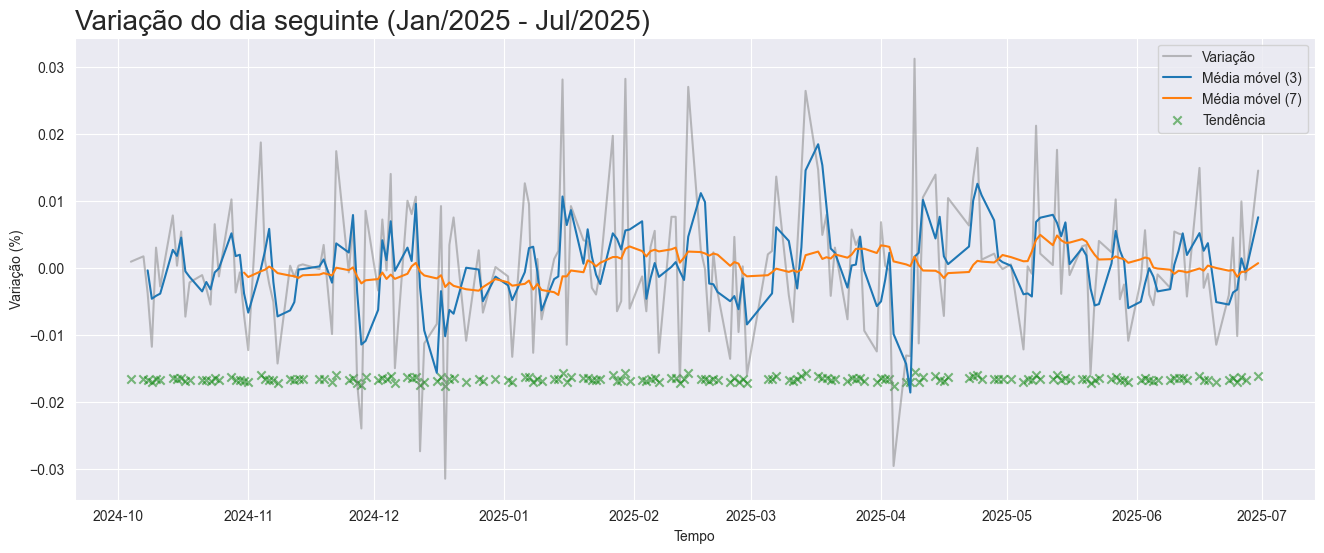

In [224]:
fig = plt.figure(figsize=(16, 6))

ax = plt.subplot()

to_plot = 'var'

period = -30*6

ax.plot(
    df[period:][to_plot],
    label = 'Variação',
    color='gray',
    alpha = 0.5
)

ax.plot(
    df[period:][to_plot].rolling(3).mean(),
    label = 'Média móvel (3)'
)

ax.plot(
    df[period:][to_plot].rolling(20).mean(),
    label = 'Média móvel (7)'
)

# ax.plot(
#     df[period:][to_plot].rolling(3).std(),
#     label = 'std3'
# )

ax.scatter(
    df[period:].index,
    (df[period:]['var'] - 0.5)/30,
    color = 'g',
    marker = 'x',
    alpha = 0.5,
    label = 'Tendência'
)

ax.set_xlabel('Tempo')
ax.set_ylabel('Variação (%)')

ax.legend()

set_ax_title(
    ax,
    title = 'Variação do dia seguinte (Jan/2025 - Jul/2025)',
)


# export_fig(fig = fig,
#            file_name='lineplot_basic',
#            tight = True)

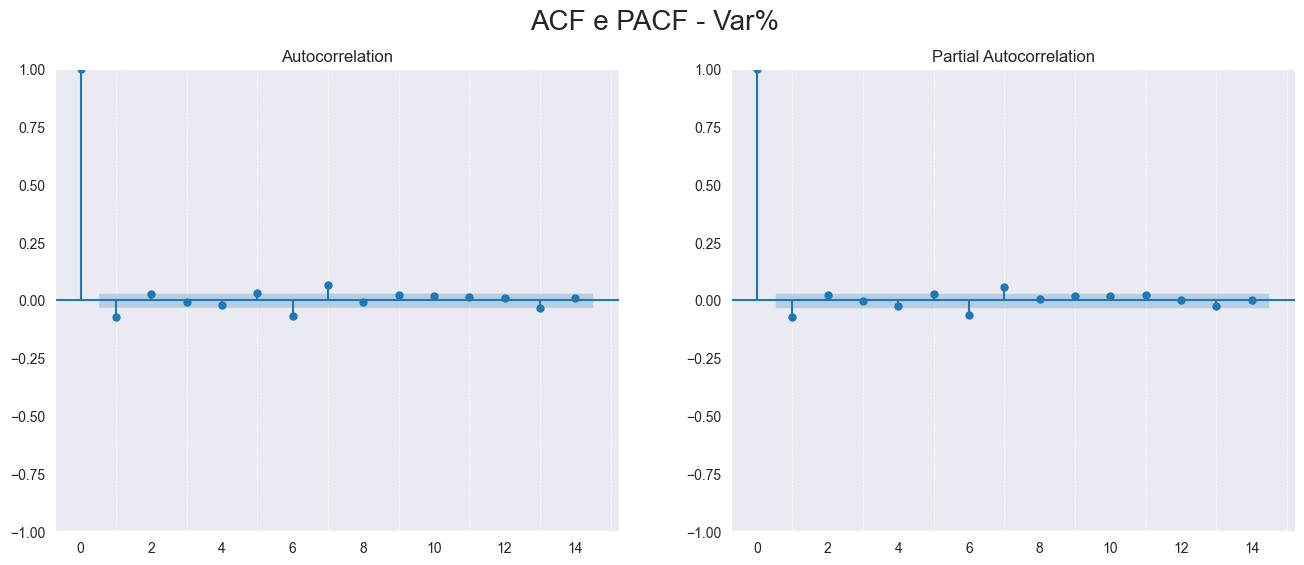

In [225]:
lags = 14

to_plot = 'var'

fig, axs = plt.subplots(
    nrows = 1,
    ncols = 2,
    figsize = (16, 6)
)

fig.suptitle(
    f'ACF e PACF - {col_dict[to_plot]}',
    fontsize = 20
)

ax = axs[0]
plot_acf(
    df[to_plot],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)

ax = axs[1]
plot_pacf(
    df[to_plot],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)

plt.show()

# export_fig(
#     fig,
#     'acf_pacf',
# )


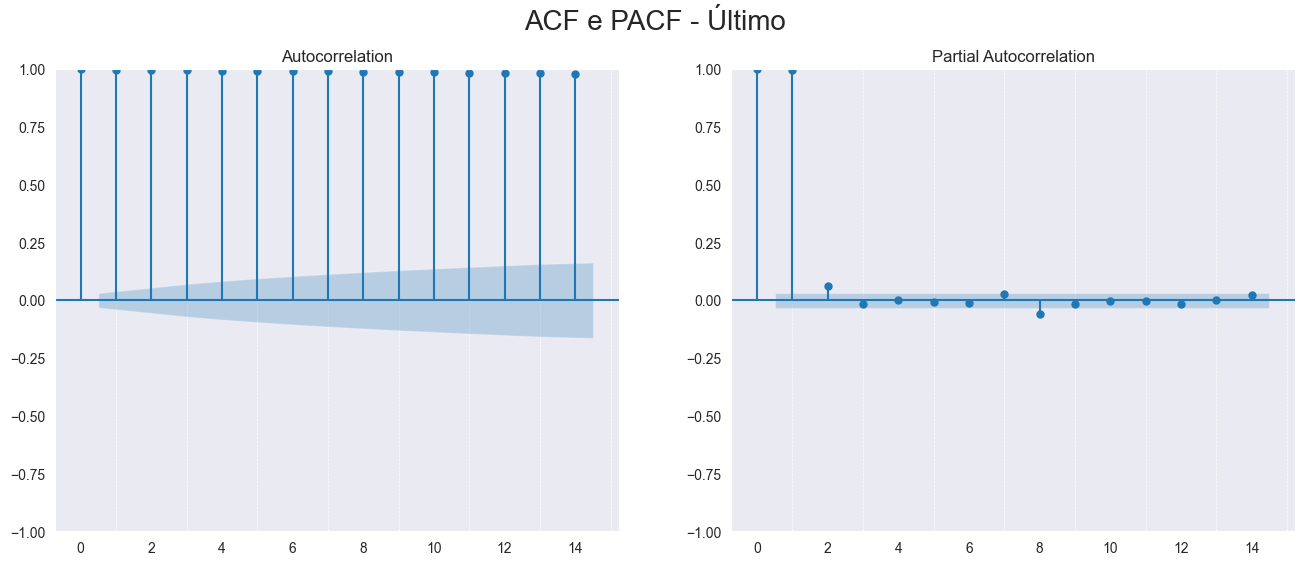

In [226]:
lags = 14

to_plot = 'ultimo'

fig, axs = plt.subplots(
    nrows = 1,
    ncols = 2,
    figsize = (16, 6)
)

fig.suptitle(
    f'ACF e PACF - {col_dict[to_plot]}',
    fontsize = 20
)

ax = axs[0]
plot_acf(
    df[to_plot],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)

ax = axs[1]
plot_pacf(
    df[to_plot],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)

plt.show()

# export_fig(
#     fig,
#     'fechamento_acf_pacf',
# )


# 2. Features & Targets

In [227]:
dataset = pd.DataFrame()

df.head(3)

,ultimo,abertura,maxima,minima,var,volume
data,,,,,,
2010-01-29,65.402,65.591,66.576,65.140,-0.0028,1820000.0
2010-02-01,66.572,65.402,66.763,65.362,0.0179,1490000.0
2010-02-02,67.163,66.589,67.321,66.539,0.0089,1590000.0


In [228]:
# Today's closing value (will be deleted later)
dataset['close_TBD'] = df['ultimo']

# Difference between today and yesterday
delta = dataset['close_TBD'].diff()

# If the variation is smaller than this, we will disregard it
THRESHOLD = 0.005

# Did the price increase from yesterday? 1 if yes, 0 if no
dataset['target'] = np.where(
    delta > THRESHOLD, 1,
    np.where( delta < -THRESHOLD, 0, np.nan)
)

dataset.head(3)


,close_TBD,target
data,,
2010-01-29,65.402,NaN
2010-02-01,66.572,1.0
2010-02-02,67.163,1.0


In [229]:
# Difference between yesterday and the day before (yesterday's delta)
dataset['delta'] = delta.shift(1)

# Percentage variation between the previous day and the day before that (Yesterday's pct_change)
dataset['return'] = dataset['close_TBD'].pct_change().shift(1)

dataset.head(3)

,close_TBD,target,delta,return
data,,,,
2010-01-29,65.402,NaN,NaN,NaN
2010-02-01,66.572,1.0,NaN,NaN
2010-02-02,67.163,1.0,1.17,0.017889


In [230]:
def make_n_lags(
        df : pd.DataFrame,
        n_lags : int,
        column : str
):
    for i in range(
        1,
        n_lags + 1
    ):
        df[f'{column}_lag{i}'] = df[column].shift(i)
    return df

In [231]:
n_lags = 10

dataset = make_n_lags(
    df = dataset,
    n_lags = n_lags,
    column = 'target'
)

dataset.tail(3)

,close_TBD,target,delta,return,target_lag1,target_lag2,target_lag3,target_lag4,target_lag5,target_lag6,target_lag7,target_lag8,target_lag9,target_lag10
data,,,,,,,,,,,,,,
2025-06-26,137.114,1.0,-1.398,-0.010192,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
2025-06-27,136.866,0.0,1.347,0.009921,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2025-06-30,138.855,1.0,-0.248,-0.001809,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [232]:
# Yesterday's min and max
dataset['high'] = df['maxima'].shift(1)
dataset['low'] = df['minima'].shift(1)

dataset.tail(3)

,close_TBD,target,delta,return,target_lag1,target_lag2,target_lag3,target_lag4,target_lag5,target_lag6,target_lag7,target_lag8,target_lag9,target_lag10,high,low
data,,,,,,,,,,,,,,,,
2025-06-26,137.114,1.0,-1.398,-0.010192,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,137.163,135.565
2025-06-27,136.866,0.0,1.347,0.009921,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,137.353,135.756
2025-06-30,138.855,1.0,-0.248,-0.001809,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,137.209,136.469


In [233]:
# Refers to yesterday's high and low
dataset['volatility'] = dataset['high'] - dataset['low']
dataset['volatility_relative'] = dataset['volatility'] / dataset['low']

dataset.tail(3)

,close_TBD,target,delta,return,target_lag1,target_lag2,target_lag3,target_lag4,target_lag5,target_lag6,target_lag7,target_lag8,target_lag9,target_lag10,high,low,volatility,volatility_relative
data,,,,,,,,,,,,,,,,,,
2025-06-26,137.114,1.0,-1.398,-0.010192,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,137.163,135.565,1.598,0.011788
2025-06-27,136.866,0.0,1.347,0.009921,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,137.353,135.756,1.597,0.011764
2025-06-30,138.855,1.0,-0.248,-0.001809,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,137.209,136.469,0.740,0.005422


In [234]:
dataset['open'] = df['abertura']

## Indicators

In [235]:
## Verification for RSI calculation

# test = pd.DataFrame()

# window_length = 14

# test['close'] = df['ultimo']
# test['diff'] = test['close'].diff(1)
# test['gain'] = test['diff'].clip(lower=0).abs()
# test['loss'] = test['diff'].clip(upper=0).abs()

# test['avg_gain'] = test['gain'].rolling(window = window_length,
#                                         min_periods = window_length).mean()[:window_length+1]
# test['avg_loss'] = test['loss'].rolling(window = window_length,
#                                         min_periods = window_length).mean()[:window_length+1]

# # Get WMS averages
# # Average Gains
# for i, row in enumerate(test['avg_gain'].iloc[window_length + 1:]):
#     test['avg_gain'].iloc[i + window_length + 1] =\
#         (test['avg_gain'].iloc[i + window_length] *
#          (window_length - 1) +
#          test['gain'].iloc[i + window_length + 1])\
#         / window_length
# # Average Losses
# for i, row in enumerate(test['avg_loss'].iloc[window_length+1:]):
#     test['avg_loss'].iloc[i + window_length + 1] =\
#         (test['avg_loss'].iloc[i + window_length] *
#          (window_length - 1) +
#          test['loss'].iloc[i + window_length + 1])\
#         / window_length

# # Calculate RS Values
# test['rs'] = test['avg_gain'] / test['avg_loss']

# # Calculate RSI
# test['rsi'] = 100 - (100 / (1.0 + test['rs']))

# test.tail(15)

In [236]:
def calculate_rsi(df, periods=14, column='Close'):
    close_delta = df[column].diff()
    up = close_delta.clip(lower=0)
    down = -1 * close_delta.clip(upper=0)
    ma_up = up.ewm(com=periods - 1, adjust=False).mean()
    ma_down = down.ewm(com=periods - 1, adjust=False).mean()
    rs = ma_up / ma_down
    rsi = 100 - (100 / (1 + rs))
    return rsi

In [237]:
dataset['rsi'] = calculate_rsi(
    df = dataset,
    periods = 14,
    column = 'close_TBD'
)

dataset.tail()

,close_TBD,target,delta,return,target_lag1,target_lag2,target_lag3,target_lag4,target_lag5,target_lag6,target_lag7,target_lag8,target_lag9,target_lag10,high,low,volatility,volatility_relative,open,rsi
data,,,,,,,,,,,,,,,,,,,,
2025-06-24,137.165,1.0,-0.565,-0.004121,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,137.130,135.835,1.295,0.009534,136.552,50.552105
2025-06-25,135.767,0.0,0.614,0.004496,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,138.156,136.254,1.902,0.013959,137.163,44.373022
2025-06-26,137.114,1.0,-1.398,-0.010192,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,137.163,135.565,1.598,0.011788,135.767,50.634200
2025-06-27,136.866,0.0,1.347,0.009921,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,137.353,135.756,1.597,0.011764,137.113,49.528856
2025-06-30,138.855,1.0,-0.248,-0.001809,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,137.209,136.469,0.740,0.005422,136.865,57.535452


## Lags

In [238]:
# 1 semana útil
dataset['ma5'] = df['ultimo'].rolling(5).mean().shift(1)

# 1 mes útil
dataset['ma22'] = df['ultimo'].rolling(22).mean().shift(1)

# 3 meses úteis (trimestre)
dataset['ma66'] = df['ultimo'].rolling(66).mean().shift(1)

# 6 meses úteis (semestre)
dataset['ma132'] = df['ultimo'].rolling(132).mean().shift(1)

# 1 ano útil
dataset['ma252'] = df['ultimo'].rolling(252).mean().shift(1)

dataset.tail(3)

,close_TBD,target,delta,return,target_lag1,target_lag2,target_lag3,target_lag4,target_lag5,target_lag6,...,low,volatility,volatility_relative,open,rsi,ma5,ma22,ma66,ma132,ma252
data,,,,,,,,,,,,,,,,,,,,,
2025-06-26,137.114,1.0,-1.398,-0.010192,0.0,1.0,0.0,0.0,0.0,0.0,...,135.565,1.598,0.011788,135.767,50.634200,137.0632,137.431227,134.521394,129.366598,129.646520
2025-06-27,136.866,0.0,1.347,0.009921,1.0,0.0,1.0,0.0,0.0,0.0,...,135.756,1.597,0.011764,137.113,49.528856,136.7426,137.384773,134.599561,129.433917,129.709111
2025-06-30,138.855,1.0,-0.248,-0.001809,0.0,1.0,0.0,1.0,0.0,0.0,...,136.469,0.740,0.005422,136.865,57.535452,136.6926,137.263182,134.668061,129.489015,129.765575


## Date information

In [239]:
dataset = dataset.reset_index()

In [240]:
dataset['data'] = pd.to_datetime(dataset['data'])

dataset['weekday'] = dataset['data'].dt.day_of_week
dataset['month'] = dataset['data'].dt.month
dataset['month_day'] = dataset['data'].dt.day

## Final copy

In [244]:
df_model = dataset.dropna().copy()

# Save the dates of the train and test periods to use in the graphs later
test_dates = df_model.iloc[-n_predictions : ]['data']
train_dates = df_model.iloc[ : -n_predictions]['data']

In [245]:
df_model = df_model.drop(
    [
        'close_TBD', 
        'volatility',
        'data',
        'ma66',
        'ma132',
        'ma252'
    ],
    axis = 1
)

***
# 3. Model Selection

## Pre-processing

In [173]:
kf_params = {
    'splits': 10,
    'shuffle': True,
    'random_state': SEED
}

kft = TimeSeriesSplit(
    n_splits = kf_params['splits'],
    test_size = n_predictions
)

In [278]:
# Ultimos 30 dias como teste
history = df_model.iloc[ : -n_predictions]
test = df_model.iloc[-n_predictions : ]

predictors = list(history.columns)
predictors.remove('target')

X_train, X_test = history[predictors], test[predictors]
y_train, y_test = history['target'], test['target']

print(f'Train {len(y_train)} | Test {len(y_test)}')
print(f'Predictors = {predictors}')

display(X_test.tail(3))
display(y_test.tail(3))

Train 3408 | Test 30
Predictors = ['delta', 'return', 'target_lag1', 'target_lag2', 'target_lag3', 'target_lag4', 'target_lag5', 'target_lag6', 'target_lag7', 'target_lag8', 'target_lag9', 'target_lag10', 'high', 'low', 'volatility_relative', 'open', 'rsi', 'ma5', 'ma22', 'weekday', 'month', 'month_day']


,delta,return,target_lag1,target_lag2,target_lag3,target_lag4,target_lag5,target_lag6,target_lag7,target_lag8,...,high,low,volatility_relative,open,rsi,ma5,ma22,weekday,month,month_day
3817,-1.398,-0.010192,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,137.163,135.565,0.011788,135.767,50.634200,137.0632,137.431227,3,6,26
3818,1.347,0.009921,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,137.353,135.756,0.011764,137.113,49.528856,136.7426,137.384773,4,6,27
3819,-0.248,-0.001809,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,137.209,136.469,0.005422,136.865,57.535452,136.6926,137.263182,0,6,30


3817    1.0
3818    0.0
3819    1.0
Name: target, dtype: float64

## Pipelines

In [175]:
pipe_lr = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            solver = 'liblinear'
        ))
    ]
)

param_grid_lr = {
    'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],  # regularização
    'clf__penalty': ['l1', 'l2'],  # tipo de penalização
    'clf__solver': ['liblinear'],  # necessário para suportar l1
}

grid_lr = GridSearchCV(
    estimator = pipe_lr,
    param_grid = param_grid_lr,
    cv = kft)

grid_lr.fit(X_train,
            y_train)


d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to conver

,estimator,Pipeline(step...liblinear'))])
,param_grid,"{'clf__C': [0.001, 0.01, ...], 'clf__penalty': ['l1', 'l2'], 'clf__solver': ['liblinear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,TimeSeriesSpl... test_size=30)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [176]:
pipe_xgb = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('clf', XGBClassifier())        
    ]
)

param_grid_xgb = {
    'clf__n_estimators': [50, 100, 200],  # número de árvores
    'clf__max_depth': [3, 5, 7],  # profundidade da árvore
    'clf__learning_rate': [0.01, 0.05, 0.1, 0.3],  # taxa de aprendizado
    'clf__subsample': [0.6, 0.8, 1.0],  # fração das amostras usadas em cada árvore
    'clf__colsample_bytree': [0.6, 0.8, 1.0],  # fração de colunas usadas por árvore
    'clf__gamma': [0, 0.1, 0.5, 1.0],  # regularização mínima para divisão
    'clf__reg_alpha': [0, 0.1, 1],  # L1 regularization
    'clf__reg_lambda': [0.1, 1, 10],  # L2 regularization
}

grid_xgb = RandomizedSearchCV(
    pipe_xgb,
    param_grid_xgb,
    n_iter = 10,
    cv = kft,
    random_state = SEED)

# grid_xgb = GridSearchCV(
#     estimator = pipe_xgb,
#     param_grid = param_grid_xgb,
#     cv = kft)

grid_xgb.fit(X_train,
             y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'clf__colsample_bytree': [0.6, 0.8, ...], 'clf__gamma': [0, 0.1, ...], 'clf__learning_rate': [0.01, 0.05, ...], 'clf__max_depth': [3, 5, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,TimeSeriesSpl... test_size=30)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,152
,error_score,nan


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

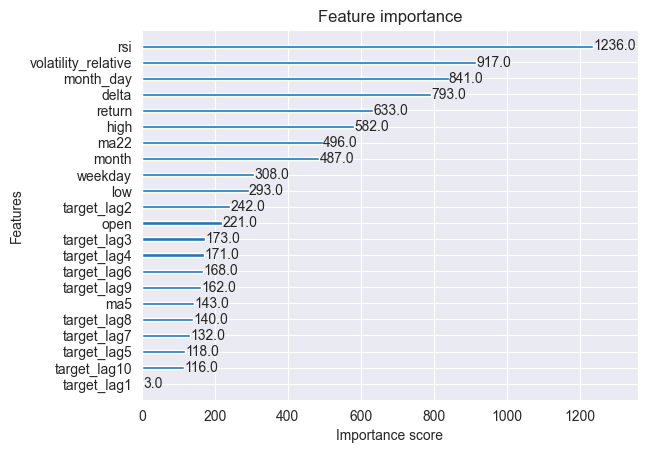

In [179]:
xgb_model = XGBClassifier(
    subsample = 0.8,
    reg_lambda = 0.1,
    reg_alpha = 0.1,
    n_estimators = 100,
    max_depth = 7,
    learning_rate = 0.01,
    gamma = 0,
    colsample_bytree = 1
)

xgb_model.fit(
    X_train,
    y_train
)

plot_importance(xgb_model)

In [180]:
pipe_lr = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            solver = 'liblinear'
        ))
    ]
)

param_grid_lr = {
    'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],  # regularização
    'clf__penalty': ['l1', 'l2'],  # tipo de penalização
    'clf__solver': ['liblinear'],  # necessário para suportar l1
}

grid_lr = GridSearchCV(
    estimator = pipe_lr,
    param_grid = param_grid_lr,
    cv = kft)

grid_lr.fit(X_train,
            y_train)

d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to conver

,estimator,Pipeline(step...liblinear'))])
,param_grid,"{'clf__C': [0.001, 0.01, ...], 'clf__penalty': ['l1', 'l2'], 'clf__solver': ['liblinear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,TimeSeriesSpl... test_size=30)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [181]:
pipe_forest = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
        ))
    ]
)

param_grid_forest = {
    'clf__n_estimators': [5, 10, 50, 100],
    'clf__max_depth': [5, 10, 25, 50, 75, 100],
    'clf__random_state': [SEED]
}

grid_forest = GridSearchCV(
    estimator = pipe_forest,
    param_grid = param_grid_forest,
    cv = kft)

grid_forest.fit(X_train,
            y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'clf__max_depth': [5, 10, ...], 'clf__n_estimators': [5, 10, ...], 'clf__random_state': [152]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,TimeSeriesSpl... test_size=30)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [182]:
pipe_knn = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(
        ))
    ]
)

param_grid_knn = {
    'clf__n_neighbors': [i for i in range(3, 20)]
}

grid_knn = GridSearchCV(
    estimator = pipe_knn,
    param_grid = param_grid_knn,
    cv = kft)

grid_knn.fit(X_train,
            y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'clf__n_neighbors': [3, 4, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,TimeSeriesSpl... test_size=30)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


# 3. Avaliação dos modelos

In [183]:
def display_model(
    grid,
    title    
):
    print(title),
    print("Melhores parâmetros:", grid.best_params_)
    print("Acurácia:", accuracy_score(y_test,
                                      grid.predict(X_test)))
    print(classification_report(
        y_test,
        grid.predict(X_test)))

In [260]:
baseline_pred = delta.shift(1) # Just repeat yesterday's value

baseline_pred = np.where(
    baseline_pred > THRESHOLD, 1, #  If difference between today and yesterday > threshold, it grew
    np.where(baseline_pred < -THRESHOLD, 0, # < threshold, it fell
             np.nan) # within the threshold, discarded
)[-30:]

# calculando a acurácia do baseline
baseline_accuracy = accuracy_score(y_test, baseline_pred)
print(f"Acurácia do baseline: {baseline_accuracy:.2f}")

Acurácia do baseline: 0.50


In [523]:
def make_pred_df(
        y_test : pd.Series,
        y_pred : pd.Series,
        dates : pd.Series
):
    '''
    Returns one DataFrame with the y_test and y_true values paired to the same datetime index (dates).

    Parameters
    *
    y_test : pandas.Series
    y_pred : pandas.Series
    dates : pandas.Series

    Returns
    *
    pandas.DataFrame
    '''
    pred = pd.DataFrame()

    # colors = {
    #     True: 'green',
    #     False: 'gray'
    # }

    pred['y'] = y_test
    pred['y_pred'] = y_pred
    pred['true'] = pred['y'] == pred['y_pred']
    # pred['true'] = pred['true'].replace(colors)

    pred.index = dates
    pred.index = pred.index.rename('date')

    return pred

In [ ]:
def make_history_df(
        y : pd.Series,
        dates : pd.Series,
        n_days : int = -1
): 
    '''
    Returns one DataFrame with y paired the given datetime index (dates). 
    If n_days > 0, return the last n days.

    Parameters
    *
    y_test : pandas.Series
    dates : pandas.Series
    n_days : int 

    Returns
    *
    pandas.DataFrame
    '''

    history = pd.DataFrame()

    history['y'] = y
    history.index = dates
    history.index = history.index.rename('date')

    if n_days > 0:
        history = history.iloc[- n_days:]
    
    return history

In [565]:
def plot_boolean_predictions(
    pred : pd.DataFrame,
    historical : pd.DataFrame,    
    delta : pd.Series,
    figsize : tuple = (16,6),   

    title : str = 'Predictions of variation of closing value',
    
    color_true : str = 'red',
    color_hist : str = 'gray',
    alpha_true : float = 0.5,

    color_pred : str = 'green',
    alpha_pred : float = 0.5,

    color_success : str = 'green',
    color_fail : str = 'gray'
):
    '''
    Plots the boolean predictions, along with the real delta values.

    Parameters
    *
    pred : pd.DataFrame
    historical : pd.DataFrame
    delta : pd.Series

    figsize : tuple
        default (16, 6)
    color_true : str
        default 'red'
    color_hist : str
        default 'gray'
    alpha_true : float
        default 0.5
    color_pred : str
        default 'green'
    alpha_pred : float
        default 0.5
    color_success : str
        default 'green'

        Color of the bars where the prediction was accurate
    color_fail : str 
        default 'gray'
        
        Color of the bars where the prediction was inaccurate

    Returns
    *
    matplotlib.Figure
    '''

    delta_values = delta.dropna().iloc[- ((len(pred) + len(historical))):]
    delta_max = float(delta_values.abs().max())

    delta_values_train = delta_values.iloc[ : - len(pred)]
    delta_values_test = delta_values.iloc[ - len(pred) : ]

    fig, ax = plt.subplots()
    fig.set_size_inches(figsize[0], figsize[1])

    # Positive values
    pred_mask = pred['y'] > 0
    hist_mask = historical['y'] > 0

    shape_up = 'x'
    shape_down = 'x'
    shape_pred = 'o'

    normalize = delta_max * 2 * 1.1

    ax.scatter(
        x = historical[hist_mask].index,
        y = (historical[hist_mask]['y'] - 0.5)*normalize,
        marker = shape_down,
        color = color_hist,
        alpha = alpha_true,
        label = 'Historical direction'
    )


    ax.scatter(
        x = pred[pred_mask].index,
        y = (pred[pred_mask]['y'] - 0.5)*normalize,
        marker = shape_up,
        color = color_true,
        alpha = alpha_true,
        label = 'Expected direction'
    )

    # Negative values
    pred_mask = ~pred_mask
    hist_mask = ~hist_mask

    ax.scatter(
        x = pred[pred_mask].index,
        y = (pred[pred_mask]['y'] - 0.5)*normalize,
        marker = shape_down,
        color = color_true,
        alpha = alpha_true
    )

    ax.scatter(
        x = historical[hist_mask].index,
        y = (historical[hist_mask]['y'] - 0.5)*normalize,
        marker = shape_down,
        color = color_hist,
        alpha = alpha_true
    )

    # Predicted values
    ax.scatter(
        x = pred['y_pred'].index,
        y = (pred['y_pred'] - 0.5)*normalize,
        marker = shape_pred,
        color = color_pred,
        alpha = alpha_pred,
        s = 50,
        label = 'Predicted direction'
    )

    color_bar = 'lightgray'

    color = pred['true']
    color = color.replace(
        {True : color_success,
         False : color_fail}
    )

    # Bars
    ax.bar(
        x = pred['y_pred'].index,
        height = delta_values_test,
        color = color
    )

    # print(delta_values)
    # print(len(historical))
    # print(len(delta_values.iloc[- (len('y_pred') + len(historical)): -len(pred['y_pred'])]))

    ax.bar(
        x = historical['y'].index,
        height = delta_values_train,
        color = color_bar
    )

    ax.set_ylabel('Variation of closing value between that day and the previous')
    ax.set_title(title,
                 fontsize = 20,
                 loc = 'left')

    plt.legend()

    return fig

In [566]:
def export_fig(
        fig,
        file_name,
        tight = True
):
    if tight:
        plt.tight_layout()
    fig.savefig(f'plots/{file_name}.png')

In [567]:
def plot_boolean_predictions_direct(
        y_train : pd.Series,
        y_test : pd.Series,
        y_pred : pd.Series,
        train_dates : pd.Series,
        test_dates : pd.Series,
        delta : pd.Series,
        n_days : int = 15,
        export_name : str = '',
        export : bool = False,
        **kwargs
):
    historical = make_history_df(
        y = y_train,
        dates = train_dates,
        n_days = n_days
    )

    pred = make_pred_df(
        y_test = y_test,
        y_pred = y_pred,
        dates = test_dates
    )

    fig = plot_boolean_predictions(
        pred = pred,
        historical = historical,
        delta = delta,
        **kwargs
    )

    if export:
        export_fig(
            fig,
            file_name = export_name
        )



In [568]:
accs = {
    
}

50.00%


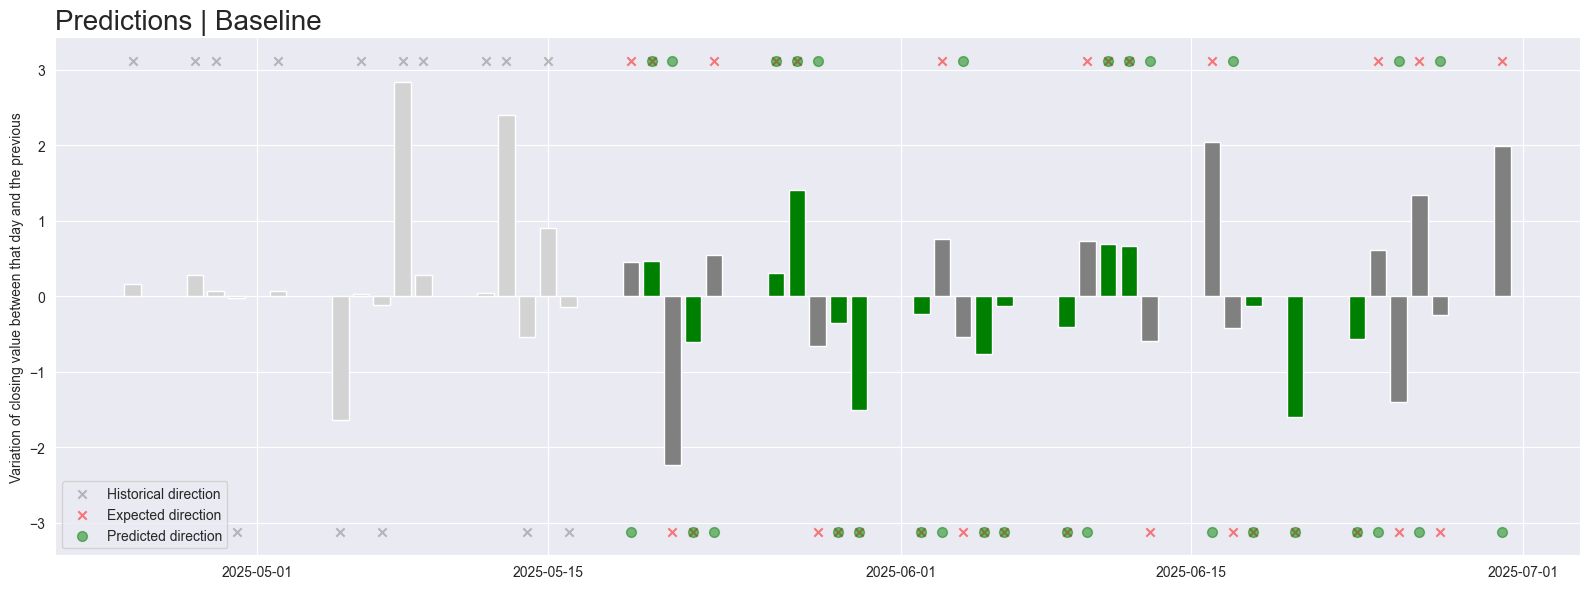

In [569]:
pred = baseline_pred
name = 'Baseline'

plot_boolean_predictions_direct(
    y_train = y_train,
    y_pred = baseline_pred,
    train_dates = train_dates,
    y_test = y_test,
    test_dates = test_dates,
    delta = delta,
    n_days = 15,
    export_name = f'prediction_{name}',
    export = True,
    title = f'Predictions | {name}'
)

accs[name] = accuracy_score(y_test, pred)
print(f'{accs[name]*100:.2f}%')

63.33%


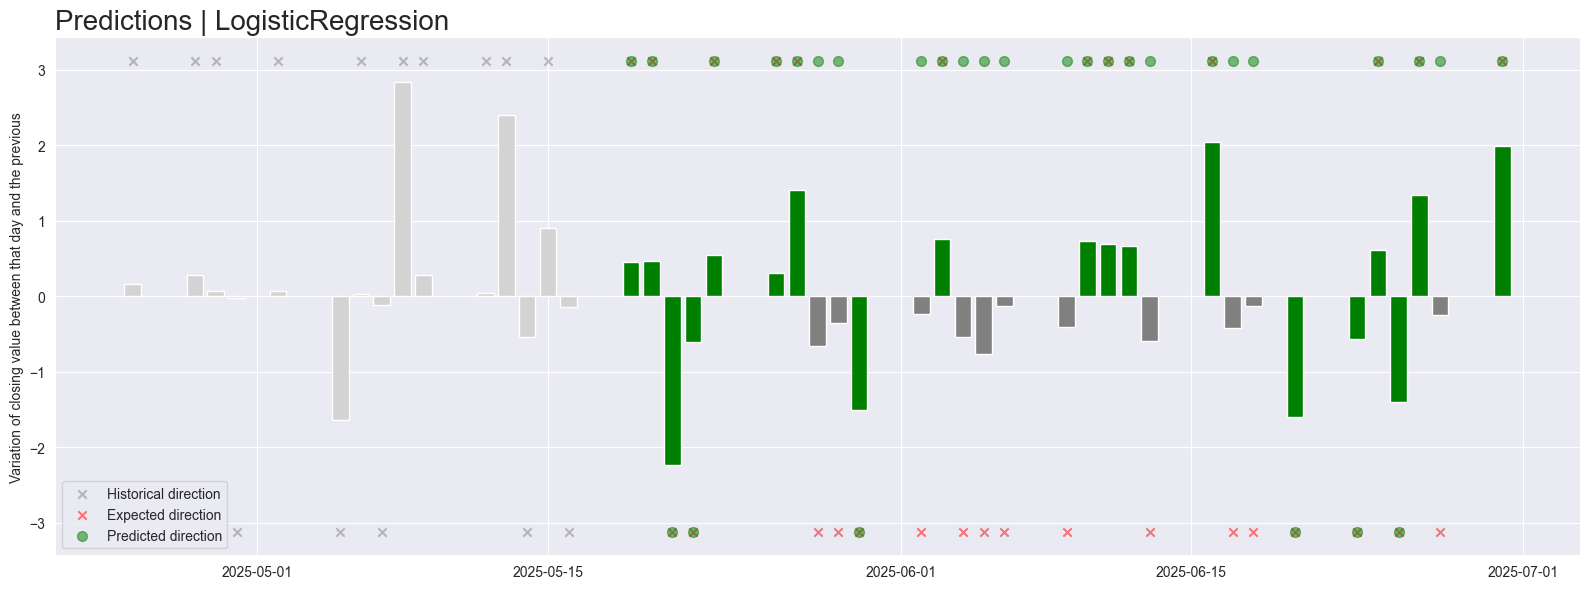

In [570]:
pred = grid_lr.predict(X_test)
name = 'LogisticRegression'

plot_boolean_predictions_direct(
    y_train = y_train,
    y_pred = pred,
    train_dates = train_dates,
    y_test = y_test,
    test_dates = test_dates,
    delta = delta,
    n_days = 15,
    export_name = f'prediction_{name}',
    export = True,
    title = f'Predictions | {name}'
)

accs[name] = accuracy_score(y_test, pred)
print(f'{accs[name]*100:.2f}%')

70.00%


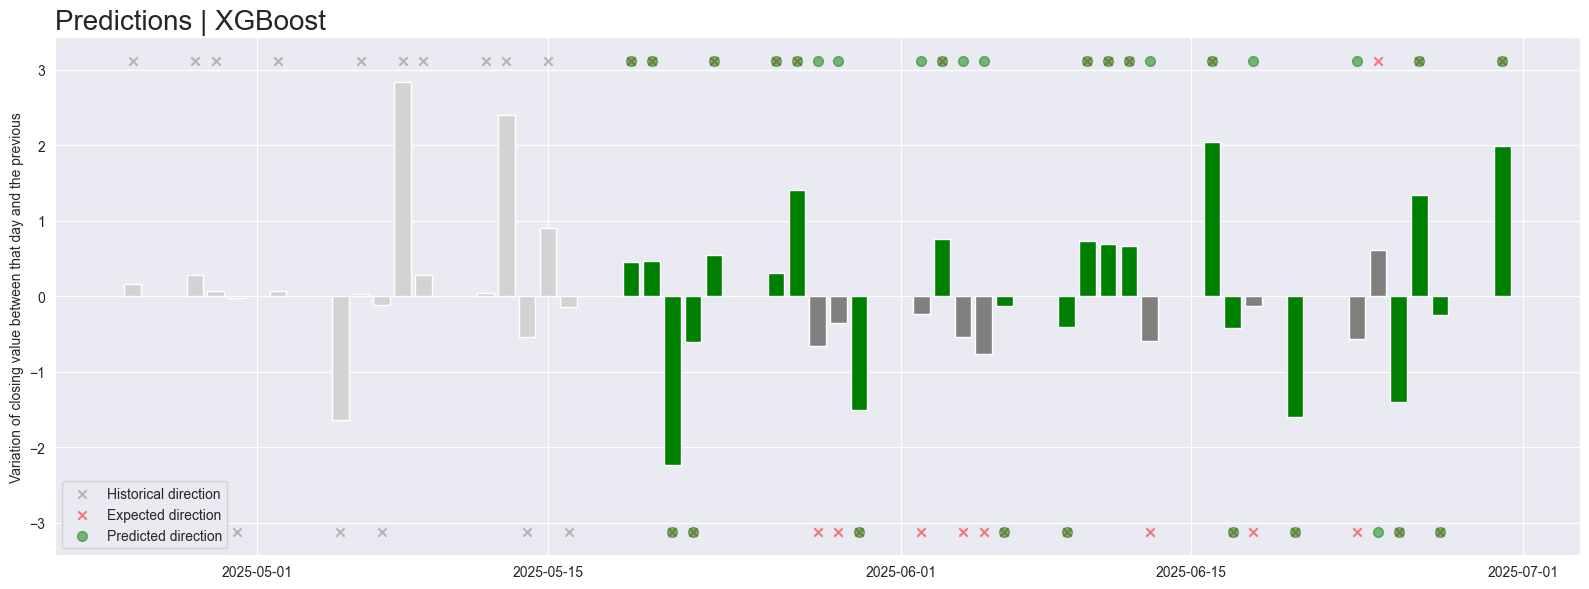

In [571]:
pred = grid_xgb.predict(X_test)
name = 'XGBoost'

plot_boolean_predictions_direct(
    y_train = y_train,
    y_pred = pred,
    train_dates = train_dates,
    y_test = y_test,
    test_dates = test_dates,
    delta = delta,
    n_days = 15,
    export_name = f'prediction_{name}',
    export = True,
    title = f'Predictions | {name}'
)

accs[name] = accuracy_score(y_test, pred)
print(f'{accs[name]*100:.2f}%')

63.33%


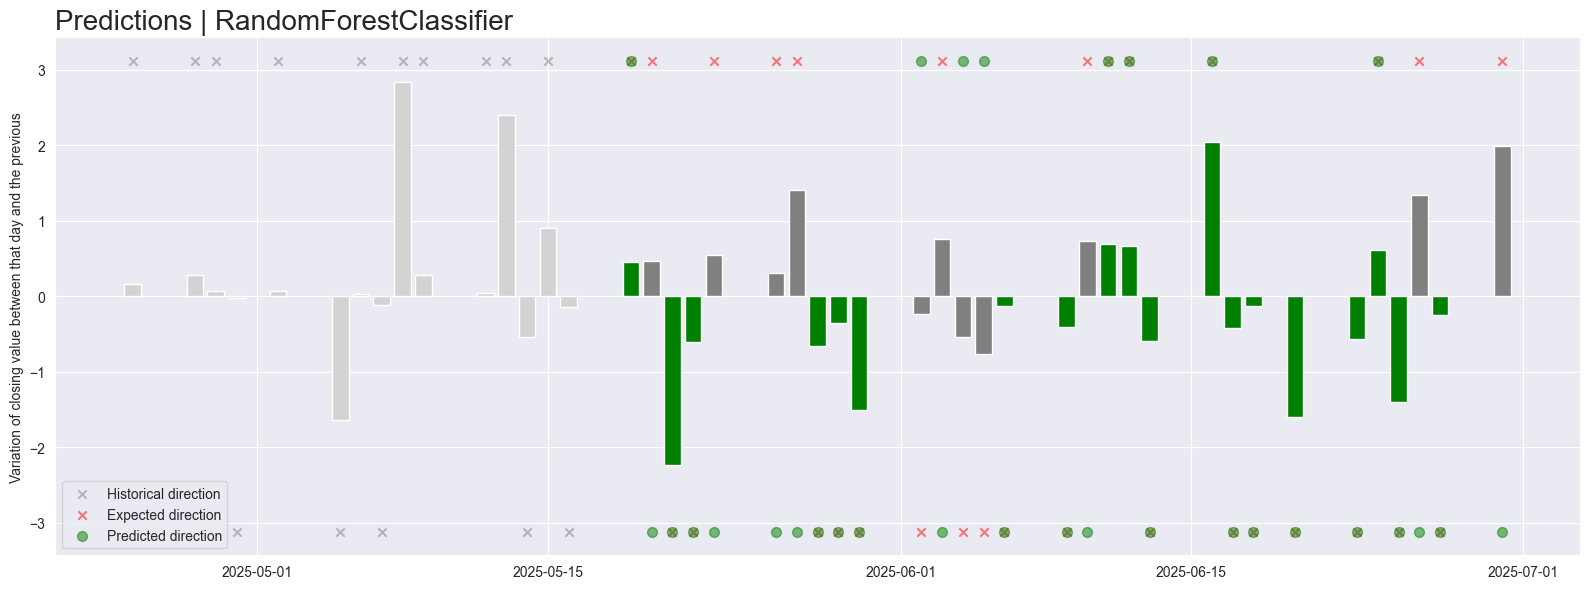

In [572]:
pred = grid_forest.predict(X_test)
name = 'RandomForestClassifier'

plot_boolean_predictions_direct(
    y_train = y_train,
    y_pred = pred,
    train_dates = train_dates,
    y_test = y_test,
    test_dates = test_dates,
    delta = delta,
    n_days = 15,
    export_name = f'prediction_{name}',
    export = True,
    title = f'Predictions | {name}'
)

accs[name] = accuracy_score(y_test, pred)
print(f'{accs[name]*100:.2f}%')

66.67%


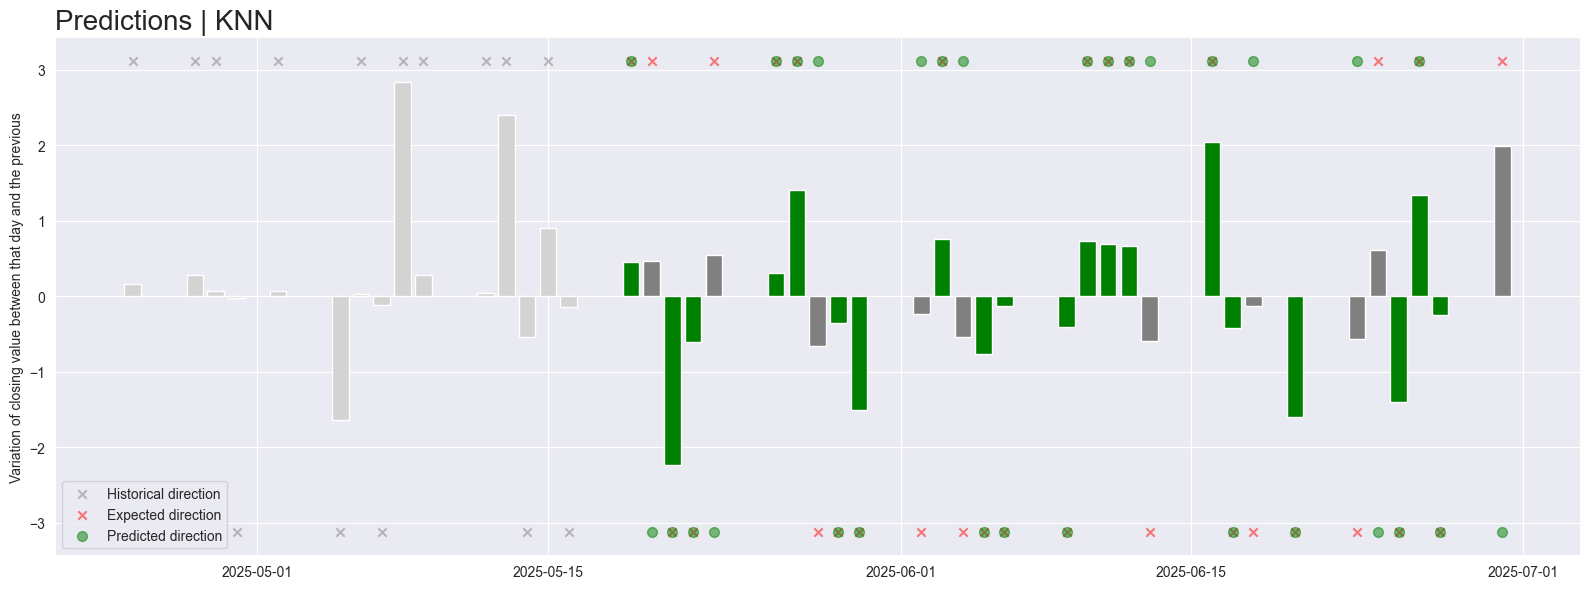

In [573]:
pred = grid_knn.predict(X_test)
name = 'KNN'

plot_boolean_predictions_direct(
    y_train = y_train,
    y_pred = pred,
    train_dates = train_dates,
    y_test = y_test,
    test_dates = test_dates,
    delta = delta,
    n_days = 15,
    export_name = f'prediction_{name}',
    export = True,
    title = f'Predictions | {name}'
)

accs[name] = accuracy_score(y_test, pred)
print(f'{accs[name]*100:.2f}%')

In [574]:
display_model(
    grid = grid_lr,
    title = 'Logistic Regression'
)

display_model(
    grid = grid_xgb,
    title = 'XGBoost'
)

display_model(
    grid = grid_forest,
    title = 'RandomForestClassifier'
)

display_model(
    grid = grid_knn,
    title = 'KNN'
)

Logistic Regression
Melhores parâmetros: {'clf__C': 100, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
Acurácia: 0.6333333333333333
              precision    recall  f1-score   support

         0.0       1.00      0.35      0.52        17
         1.0       0.54      1.00      0.70        13

    accuracy                           0.63        30
   macro avg       0.77      0.68      0.61        30
weighted avg       0.80      0.63      0.60        30

XGBoost
Melhores parâmetros: {'clf__subsample': 1.0, 'clf__reg_lambda': 10, 'clf__reg_alpha': 0.1, 'clf__n_estimators': 200, 'clf__max_depth': 5, 'clf__learning_rate': 0.05, 'clf__gamma': 0, 'clf__colsample_bytree': 0.8}
Acurácia: 0.7
              precision    recall  f1-score   support

         0.0       0.90      0.53      0.67        17
         1.0       0.60      0.92      0.73        13

    accuracy                           0.70        30
   macro avg       0.75      0.73      0.70        30
weighted avg       0.77      0

In [575]:
# # acurácia dos modelos


# # xgboost
# xgb_accuracy = accuracy_score(y_test, grid_xgb.predict(X_test))

# # randomforestclassifier
# forest_accuracy = accuracy_score(y_test, grid_forest.predict(X_test))

# # KNN
# knn_accuracy = accuracy_score(y_test, grid_knn.predict(X_test))


# # criando a tabela de comparação
# tabela_comparativa = pd.DataFrame(columns=['model', 'accuracy'])

# i = 0

# tabela_comparativa.loc[i] = ['Baseline', f"{baseline_accuracy*100:.2f}%"]
# i += 1

# tabela_comparativa.loc[i] = ['Logistic Regression', f"{log_reg_accuracy*100:.2f}%"]
# i += 1

# tabela_comparativa.loc[i] = ['XGBoost', f"{xgb_accuracy*100:.2f}%"]
# i += 1

# tabela_comparativa.loc[i] = ['RandomForestClassifier', f"{forest_accuracy*100:.2f}%"]
# i += 1

# tabela_comparativa.loc[i] = ['KNN', f"{knn_accuracy*100:.2f}%"]
# i += 1

for key in accs.keys():
    tabela_comparativa.loc[i] = [key, f'{accs[key]*100:2f}%'] 
    i += 1


tabela_comparativa

,model,accuracy
0,Baseline,50.00%
1,Logistic Regression,63.33%
2,XGBoost,70.00%
3,RandomForestClassifier,63.33%
4,KNN,66.67%
5,LogisticRegression,63.333333%
6,XGBoost,70.000000%
7,Baseline,50.000000%
8,LogisticRegression,63.333333%
9,XGBoost,70.000000%
